启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已使用标准RGB数据生成器。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别计数: [705, 717, 281, 4772, 2524, 1982, 1290]
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}
58889256/58889256 [==============================] - 98s 2us/step
VGG16: 已加载 ImageNet 预训练权重。
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 96, 96, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 96, 96, 64)        1792      
                     

2025-10-07 07:31:06.812679: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101


  8/383 [..............................] - ETA: 6s - loss: 3.5542 - accuracy: 0.1289 - top2_acc: 0.2734 - precision: 0.1377 - recall: 0.0742 

2025-10-07 07:31:10.735057: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


383/383 [==============================] - ETA: 0s - loss: 2.9804 - accuracy: 0.1789 - top2_acc: 0.3508 - precision: 0.1874 - recall: 0.0830
Epoch 1: val_accuracy improved from -inf to 0.27632, saving model to models/fer2013_best_model.h5

Epoch 1/100
训练: 损失=2.9804, 准确率=0.1789, Top-2=0.3508
训练: 精确率=0.1874, 召回率=0.0830
验证: 损失=2.1423, 准确率=0.2763, Top-2=0.5030
验证: 精确率=0.4928, 召回率=0.0339
验证: F1分数=0.0634
已用时: 0.68分钟, 预计剩余: 66.83分钟
当前学习率: 0.000500
383/383 [==============================] - 40s 89ms/step - loss: 2.9804 - accuracy: 0.1789 - top2_acc: 0.3508 - precision: 0.1874 - recall: 0.0830 - val_loss: 2.1423 - val_accuracy: 0.2763 - val_top2_acc: 0.5030 - val_precision: 0.4928 - val_recall: 0.0339 - lr: 5.0000e-04
Epoch 2/100
383/383 [==============================] - ETA: 0s - loss: 2.5225 - accuracy: 0.2311 - top2_acc: 0.4156 - precision: 0.2614 - recall: 0.0804
Epoch 2: val_accuracy improved from 0.27632 to 0.29737, saving model to models/fer2013_best_model.h5

Epoch 2/100
训练: 损失=2.5225,

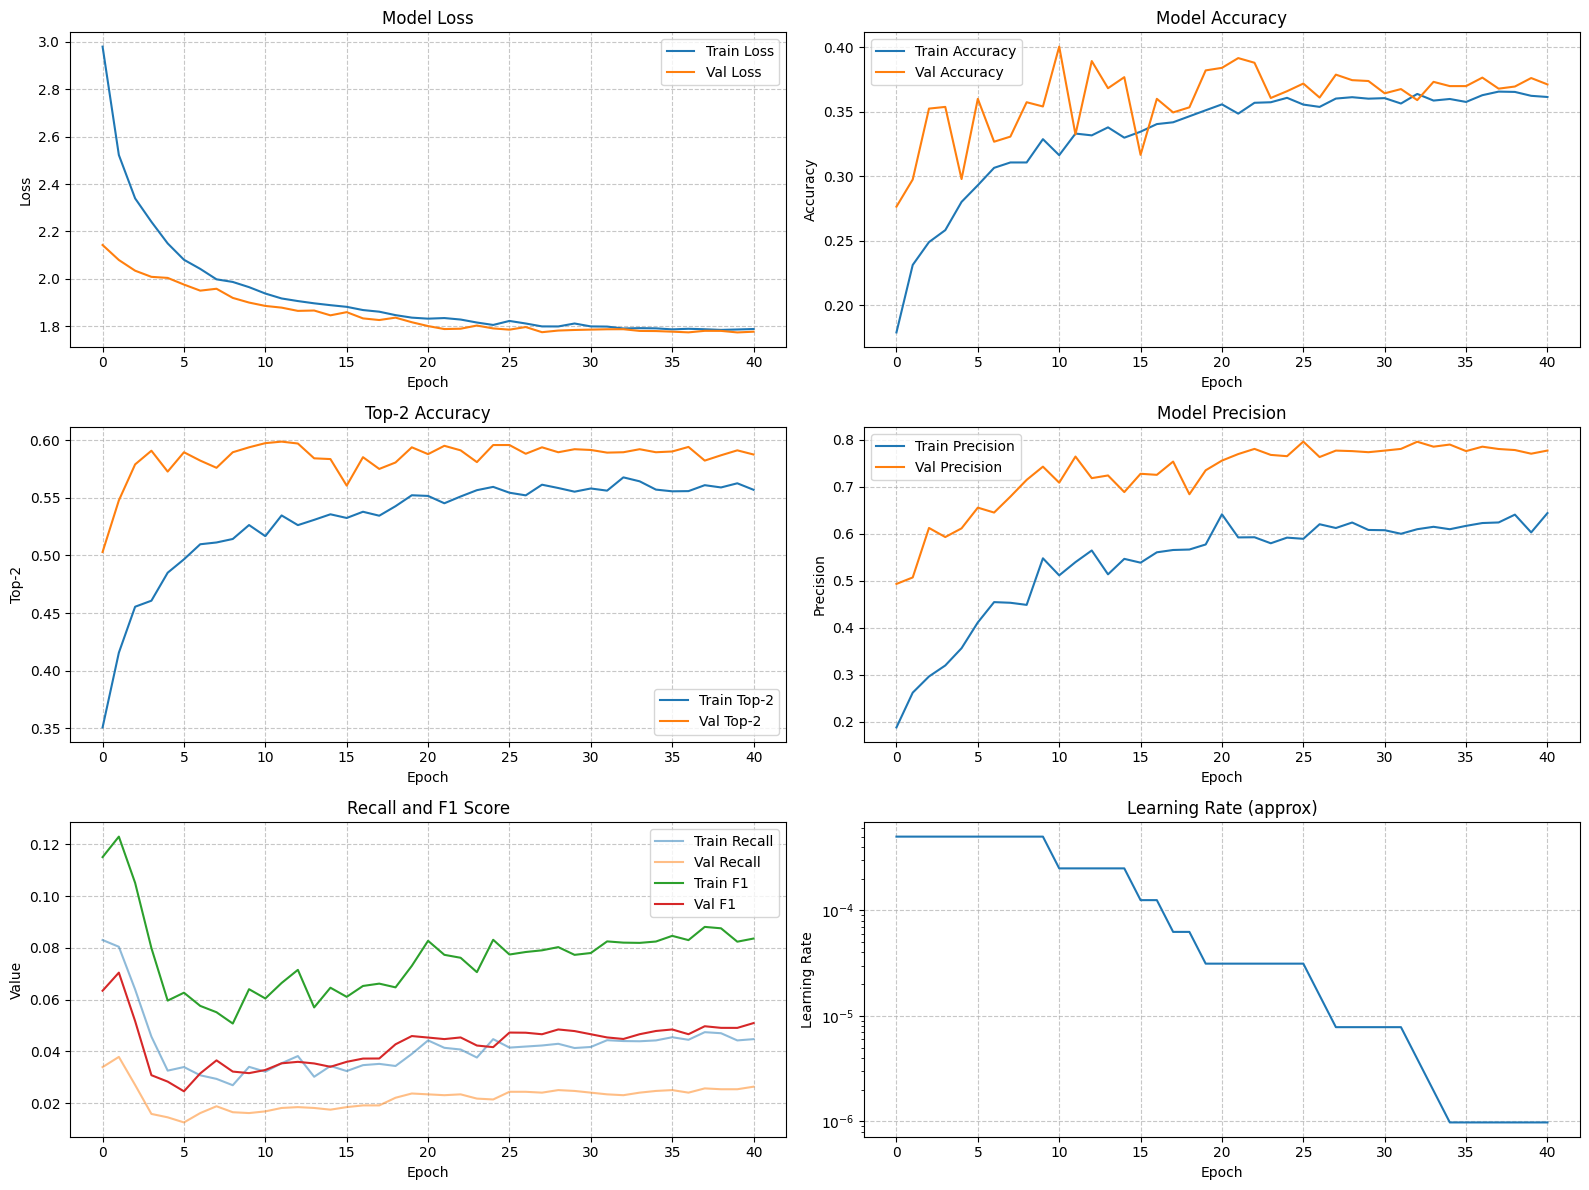

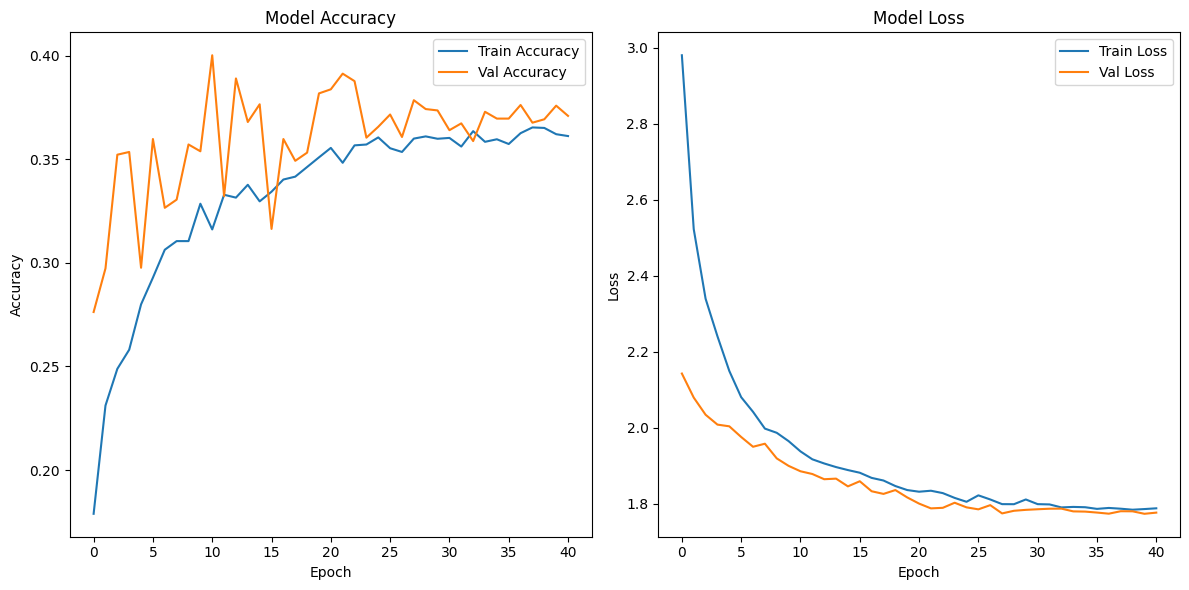

In [3]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, Input, LeakyReLU, Flatten, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, TopKCategoricalAccuracy
from tensorflow.keras.losses import CategoricalCrossentropy
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
# 新增：导入VGG16的预处理函数
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input
# 设置matplotlib字体支持
plt.rcParams["font.family"] = ["DejaVu Sans"]
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = True

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 96, 96  # 增大尺寸以获取更多人脸细节

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 32
epochs = 100

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 数据增强（适度、稳健）
        train_datagen = ImageDataGenerator(
            preprocessing_function=vgg_preprocess_input,  # 使用VGG预处理，替代 rescale
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=vgg_preprocess_input  # 验证同样使用VGG预处理
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False,
            classes=list(train_generator.class_indices.keys())  # 锁定类别顺序与训练一致
        )
        print("已使用标准RGB数据生成器。")

        # 可选：一致性断言，防止类别索引不一致
        assert validation_generator.class_indices == train_generator.class_indices, \
            f"类别索引不一致：train={train_generator.class_indices}, val={validation_generator.class_indices}"
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（应对类别不均衡）
classes_arr = train_generator.classes
class_counts = np.bincount(classes_arr)
num_classes = len(class_counts)
total_samples = classes_arr.shape[0]
class_weights = {i: total_samples / (num_classes * class_counts[i]) for i in range(num_classes)}
print("类别计数:", class_counts.tolist())
print("类别权重:", class_weights)

# 构建优化的CNN模型（使用GAP替代Flatten，降低过拟合）
l2_reg = 0.001

# 使用VGG16作为特征主干（离线/在线双通道）
try:
    base_model = VGG16(include_top=False, weights='imagenet', input_shape=(img_width, img_height, 3))
    print("VGG16: 已加载 ImageNet 预训练权重。")
except Exception as e:
    print(f"VGG16: 无法从网络获取权重，尝试本地加载或随机初始化。原因: {e}")
    base_model = VGG16(include_top=False, weights=None, input_shape=(img_width, img_height, 3))
    local_weights = os.path.join('models', 'vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5')
    if os.path.exists(local_weights):
        try:
            base_model.load_weights(local_weights)
            print(f"VGG16: 已从本地加载权重: {local_weights}")
        except Exception as le:
            print(f"VGG16: 本地权重加载失败，将使用随机初始化。原因: {le}")
    else:
        print("VGG16: 未找到本地权重，将使用随机初始化。")
base_model.trainable = False  # 冻结VGG主干，先训练顶部分类头

# VGG16 + GAP + 小型分类头
x = base_model.output
x = GlobalAveragePooling2D(name='gap')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(l2_reg))(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_labels), activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

# 编译模型：使用Label Smoothing与Top-2准确率
initial_learning_rate = 5e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        TopKCategoricalAccuracy(k=2, name='top2_acc'),
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数（监控val_accuracy）
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型（按val_accuracy）
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs.get('accuracy', 0):.4f}, Top-2={logs.get('top2_acc', 0):.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs.get('val_accuracy', 0):.4f}, Top-2={logs.get('val_top2_acc', 0):.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        class_weight=class_weights,           # 应用类别权重
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall, 'TopKCategoricalAccuracy': TopKCategoricalAccuracy}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. Loss
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. Accuracy
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # 2.1 Top-2 Accuracy
    if 'top2_acc' in history.history and 'val_top2_acc' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['top2_acc'], label='Train Top-2')
        plt.plot(history.history['val_top2_acc'], label='Val Top-2')
        plt.title('Top-2 Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Top-2')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. Precision
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Model Precision')
        plt.xlabel('Epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        # F1
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                                 history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)

        plt.subplot(3, 2, 5)
        plt.plot(history.history['recall'], label='Train Recall', alpha=0.5)
        plt.plot(history.history['val_recall'], label='Val Recall', alpha=0.5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('Recall and F1 Score')
        plt.xlabel('Epoch')
        plt.ylabel('Value')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. Learning rate (approx)
    plt.subplot(3, 2, 6)
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        if i >= reduce_lr.patience and 'val_accuracy' in history.history:
            recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
            if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                current_lr = max(current_lr * reduce_lr.factor, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate (approx)')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存单独的简化图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 简化图表
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练完成!")
print("\n使用说明:")
print("1. 训练好的模型保存在 'models/' 文件夹中:")
print("   - 'fer2013_best_model.h5': 验证集性能最佳的模型")
print("   - 'fer2013_final_model.h5': 最终训练轮次的模型")
print("2. 训练相关文件:")
print("   - 'logs/training_history.csv': 详细的训练日志")
print("   - 'logs/evaluation_results.txt': 模型评估结果")
print("   - 'plots/training_history_full.png': 完整的训练历史图表")
print("   - 'plots/training_history_simple.png': 简化的训练历史图表")
print("3. 主要优化点:")
print("   - 改为RGB输入，使用Label Smoothing与Top-2准确率")
print("   - 使用GlobalAveragePooling替代Flatten，减少参数与过拟合")
print("   - 类别权重缓解类别不均衡；以val_accuracy为准进行早停与调参")
print("   - 稳健的数据增强与学习率调度")


启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到VGG16适配的数据生成器（RGB + preprocess_input）。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                

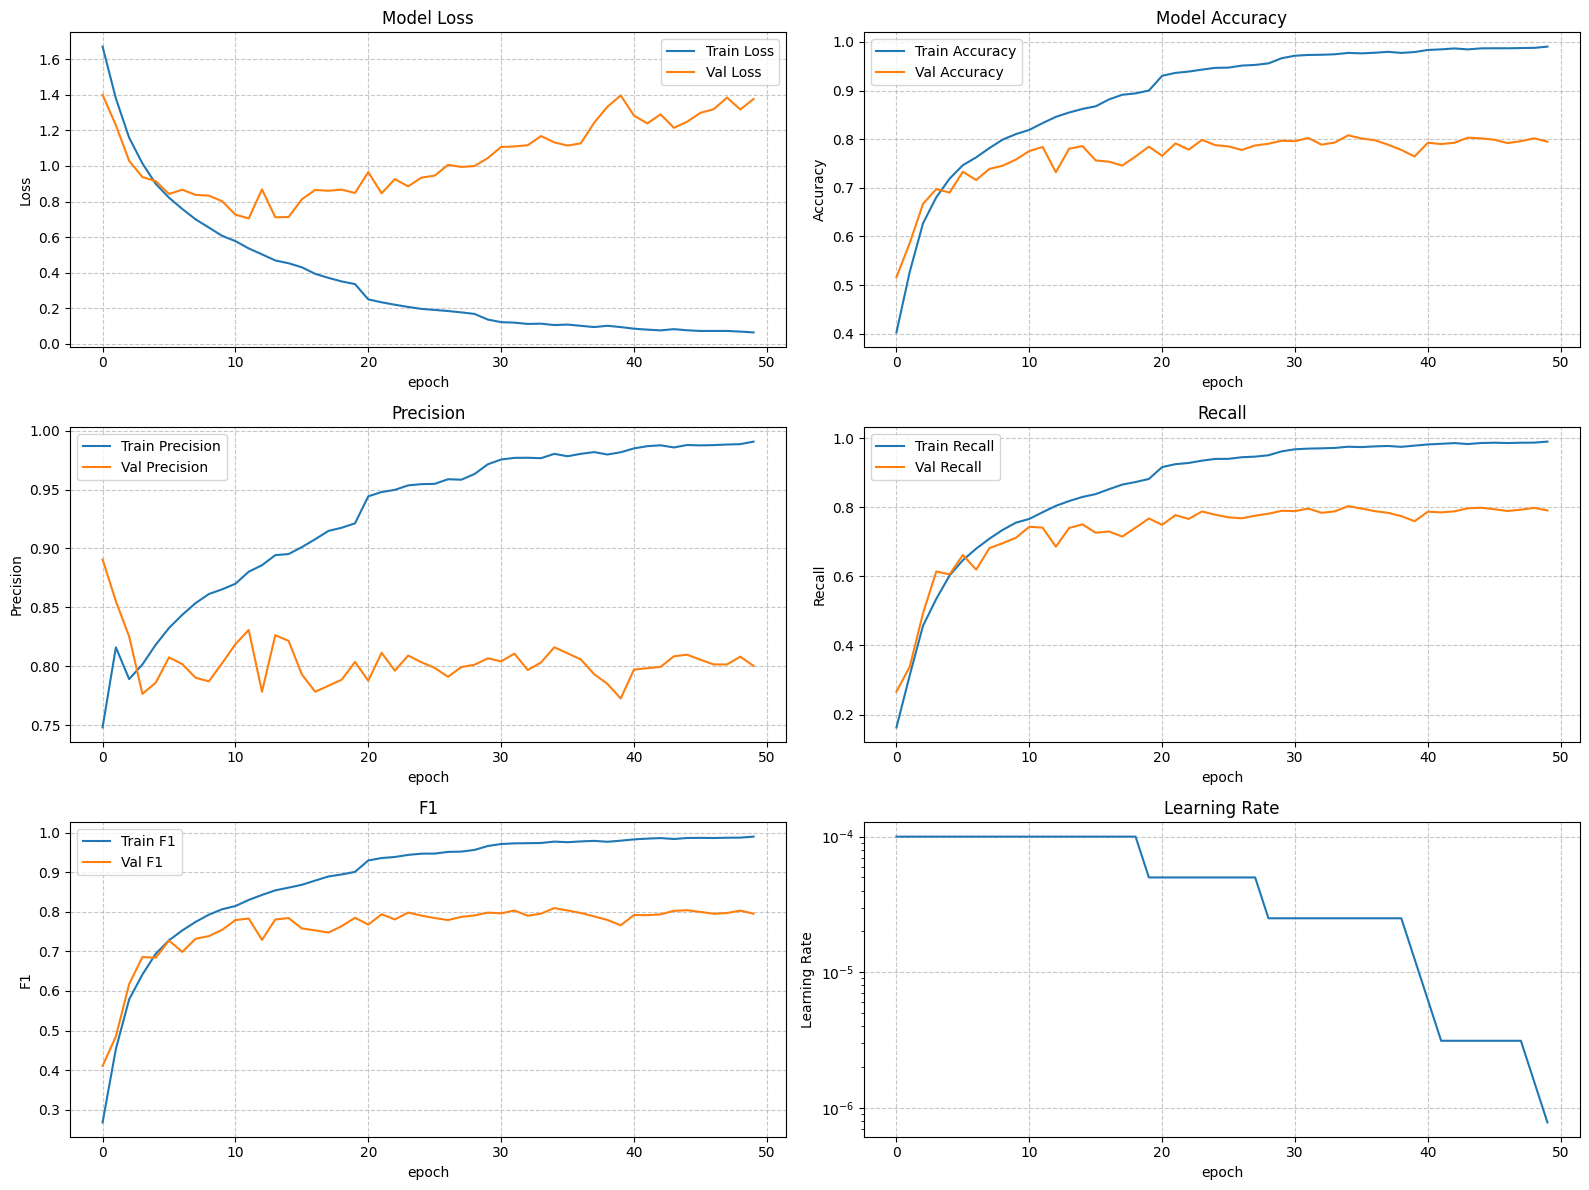

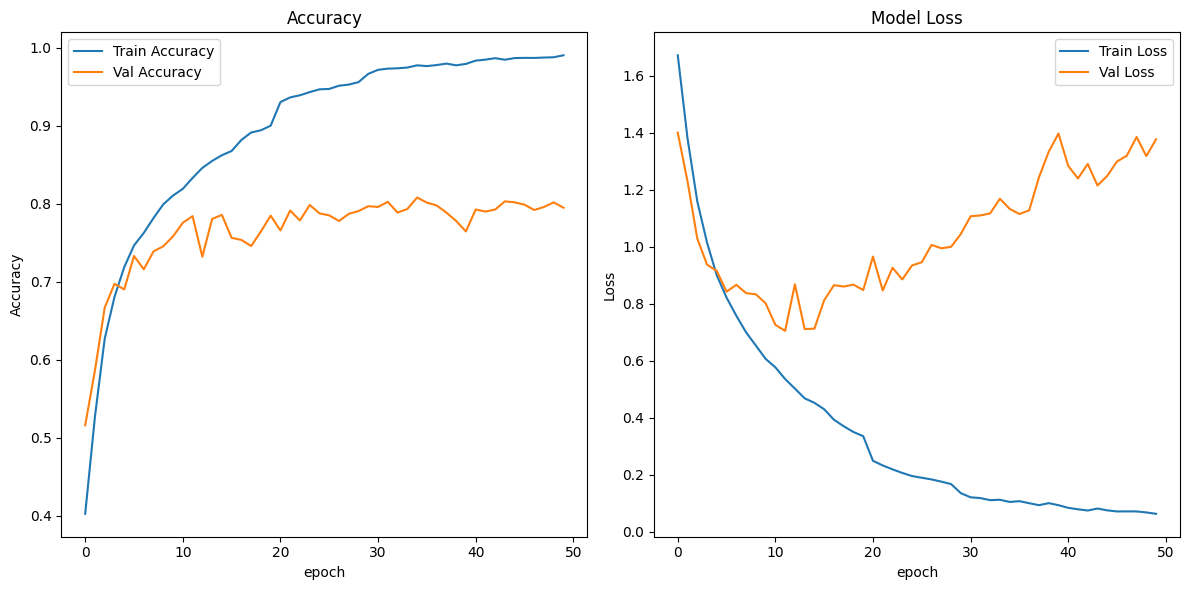

In [4]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
# 新增：VGG16 与 GAP 层、预处理函数
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 224, 224  # 使用VGG16推荐输入大小

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 16   # VGG16输入更大，适当减小batch以降低显存占用
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 使用与VGG16匹配的预处理：preprocess_input（'caffe'风格，BGR减均值），不要再rescale=1./255
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到VGG16适配的数据生成器（RGB + preprocess_input）。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 使用预训练VGG16构建模型（迁移学习 + 轻量微调）
# 替换原有的自定义CNN
inputs = Input(shape=(img_width, img_height, 3))
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

# 冻结大部分层，仅微调最后的block5以适配情绪特征
for layer in base_model.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = Dropout(0.4)(x)
outputs = Dense(len(class_labels), activation='softmax')(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 编译模型（迁移学习通常更小学习率）
initial_learning_rate = 1e-4
optimizer = Adam(learning_rate=initial_learning_rate)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[
        'accuracy',
        Precision(name='precision'),
        Recall(name='recall')
    ]
)

# 打印模型结构
model.summary()

# 创建保存目录
if not os.path.exists('models'):
    os.makedirs('models')

if not os.path.exists('logs'):
    os.makedirs('logs')

# 回调函数
early_stopping = EarlyStopping(
    monitor='val_accuracy',  # 监控验证准确率而不是损失
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=2
)

# 模型检查点 - 保存最佳模型
model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 训练模型
try:
    print("\n开始模型训练...")
    print(f"训练样本数: {train_generator.samples}")
    print(f"验证样本数: {validation_generator.samples}")
    print(f"类别数: {len(class_labels)}")
    
    # 使用所有回调函数
    callbacks = [
        early_stopping,
        reduce_lr,
        model_checkpoint,
        history_logger,
        TrainingMonitor()
    ]
    
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // batch_size,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=validation_generator.samples // batch_size,
        callbacks=callbacks,
        verbose=1
    )
except Exception as e:
    print(f"训练过程中出错: {str(e)}")
    print("如果是内存不足问题，建议减小batch_size值。")
    sys.exit(1)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练过程已完成。")

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
# 新增：VGG16 与 GAP 层、预处理函数
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 224, 224  # 使用VGG16推荐输入大小

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 16   # VGG16输入更大，适当减小batch以降低显存占用
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 使用与VGG16匹配的预处理：preprocess_input（'caffe'风格，BGR减均值），不要再rescale=1./255
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到VGG16适配的数据生成器（RGB + preprocess_input）。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（缓解类不平衡）
classes_array = train_generator.classes  # 0..K-1
class_counts = np.bincount(classes_array, minlength=len(class_labels))
total = classes_array.shape[0]
class_weights = {i: float(total / (len(class_labels) * max(1, class_counts[i]))) for i in range(len(class_labels))}
print("类别样本数:", dict(zip(class_labels, class_counts.tolist())))
print("类别权重:", class_weights)

# MixUp 生成器（同批内配对，避免跨epoch尺寸不一致）
def mixup_generator(generator, alpha=0.2):
    """对任意keras generator进行MixUp；每次仅使用一个batch内的随机配对。"""
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        b = x.shape[0]
        if b <= 1:
            # 只有1张图时跳过MixUp
            yield x, y
            continue
        lam = np.random.beta(alpha, alpha, size=b).astype(np.float32)
        idx = np.random.permutation(b)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x_mix = lam_x * x + (1.0 - lam_x) * x[idx]
        y_mix = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x_mix, y_mix

use_mixup = True
mixup_alpha = 0.2
train_generator_eff = mixup_generator(train_generator, alpha=mixup_alpha) if use_mixup else train_generator

# 使用预训练VGG16构建模型（两阶段训练 + 更强正则）
inputs = Input(shape=(img_width, img_height, 3))
base_model = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

# 第一阶段：冻结全部卷积层，只训练分类头
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
# 缩小分类头，强化正则
x = Dense(256, activation='relu', kernel_regularizer=l2(5e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_labels), activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 使用标签平滑
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# 第一阶段编译（较大学习率以训练头部）
optimizer_stage1 = Adam(learning_rate=3e-4)
model.compile(optimizer=optimizer_stage1, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# 记录初始学习率供日志与绘图使用
initial_learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))

model.summary()

# 在创建回调前，确保目录存在
os.makedirs('models', exist_ok=True)
os.makedirs('logs',   exist_ok=True)

# 回调函数（以val_loss为准，泛化更稳）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=1
)

model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 两阶段训练
epochs_stage1 = min(20, epochs // 3)
epochs_stage2 = epochs - epochs_stage1

print("\n开始阶段一（冻结卷积层，仅训练分类头）...")
history1 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_stage1,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,  # MixUp通常可不加权重
    verbose=1
)

# 阶段二：解冻block5进行微调，低学习率
for layer in base_model.layers:
    layer.trainable = layer.name.startswith('block5')

optimizer_stage2 = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_stage2, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

print("\n开始阶段二（解冻block5微调）...")
history2 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_stage2,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,
    verbose=1
)

# 合并历史，便于后续绘图
def _merge_history(h1, h2):
    for k, v in h2.history.items():
        h1.history.setdefault(k, [])
        h1.history[k].extend(v)
    return h1

history = _merge_history(history1, history2)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练过程已完成。")

2025-10-07 14:48:02.551651: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 14:48:02.665551: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 14:48:04.578627: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 14:48:05.224861: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到VGG16适配的数据生成器（RGB + preprocess_input）。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别样本数: {'anger': 705, 'disgust': 717, 'fear': 281, 'happy': 4772, 'normal': 2524, 'sad': 1982, 'surprised': 1290}
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}


2025-10-07 14:48:08.911621: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 14:48:10.408011: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-07 14:48:10.408063: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17982 MB memory:  -> device: 0, name: P1.gpu.small, pci bus id: 0000:35:00.0, compute capability: 8.0


14622720/58889256 [======>.......................] - ETA: 35:00

KeyboardInterrupt: 

2025-10-07 15:13:47.149838: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 15:13:47.269641: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-07 15:13:49.090919: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-07 15:13:49.711854: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到VGG16适配的数据生成器（RGB + preprocess_input）。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别样本数: {'anger': 705, 'disgust': 717, 'fear': 281, 'happy': 4772, 'normal': 2524, 'sad': 1982, 'surprised': 1290}
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}


2025-10-07 15:13:54.172183: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-07 15:13:55.558774: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-07 15:13:55.558828: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 17982 MB memory:  -> device: 0, name: P1.gpu.small, pci bus id: 0000:35:00.0, compute capability: 8.0


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

2025-10-07 15:14:00.293598: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101


  1/766 [..............................] - ETA: 2:00:48 - loss: 5.4090 - accuracy: 0.4375 - precision: 0.6250 - recall: 0.3226

2025-10-07 15:14:06.946100: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


766/766 [==============================] - ETA: 0s - loss: 2.1986 - accuracy: 0.3638 - precision: 0.5832 - recall: 0.1115
Epoch 1: val_loss improved from inf to 1.75054, saving model to models/fer2013_best_model.h5

Epoch 1/100
训练: 损失=2.1986, 准确率=0.3638
训练: 精确率=0.5832, 召回率=0.1115
验证: 损失=1.7505, 准确率=0.4382
验证: 精确率=0.6182, 召回率=0.2448
验证: F1分数=0.3507
已用时: 2.45分钟, 预计剩余: 242.44分钟
当前学习率: 0.000300
766/766 [==============================] - 147s 180ms/step - loss: 2.1986 - accuracy: 0.3638 - precision: 0.5832 - recall: 0.1115 - val_loss: 1.7505 - val_accuracy: 0.4382 - val_precision: 0.6182 - val_recall: 0.2448 - lr: 3.0000e-04
Epoch 2/20
766/766 [==============================] - ETA: 0s - loss: 1.8040 - accuracy: 0.4325 - precision: 0.7789 - recall: 0.1038
Epoch 2: val_loss improved from 1.75054 to 1.67492, saving model to models/fer2013_best_model.h5

Epoch 2/100
训练: 损失=1.8040, 准确率=0.4325
训练: 精确率=0.7789, 召回率=0.1038
验证: 损失=1.6749, 准确率=0.4800
验证: 精确率=0.7843, 召回率=0.1571
验证: F1分数=0.2617
已用时: 4.

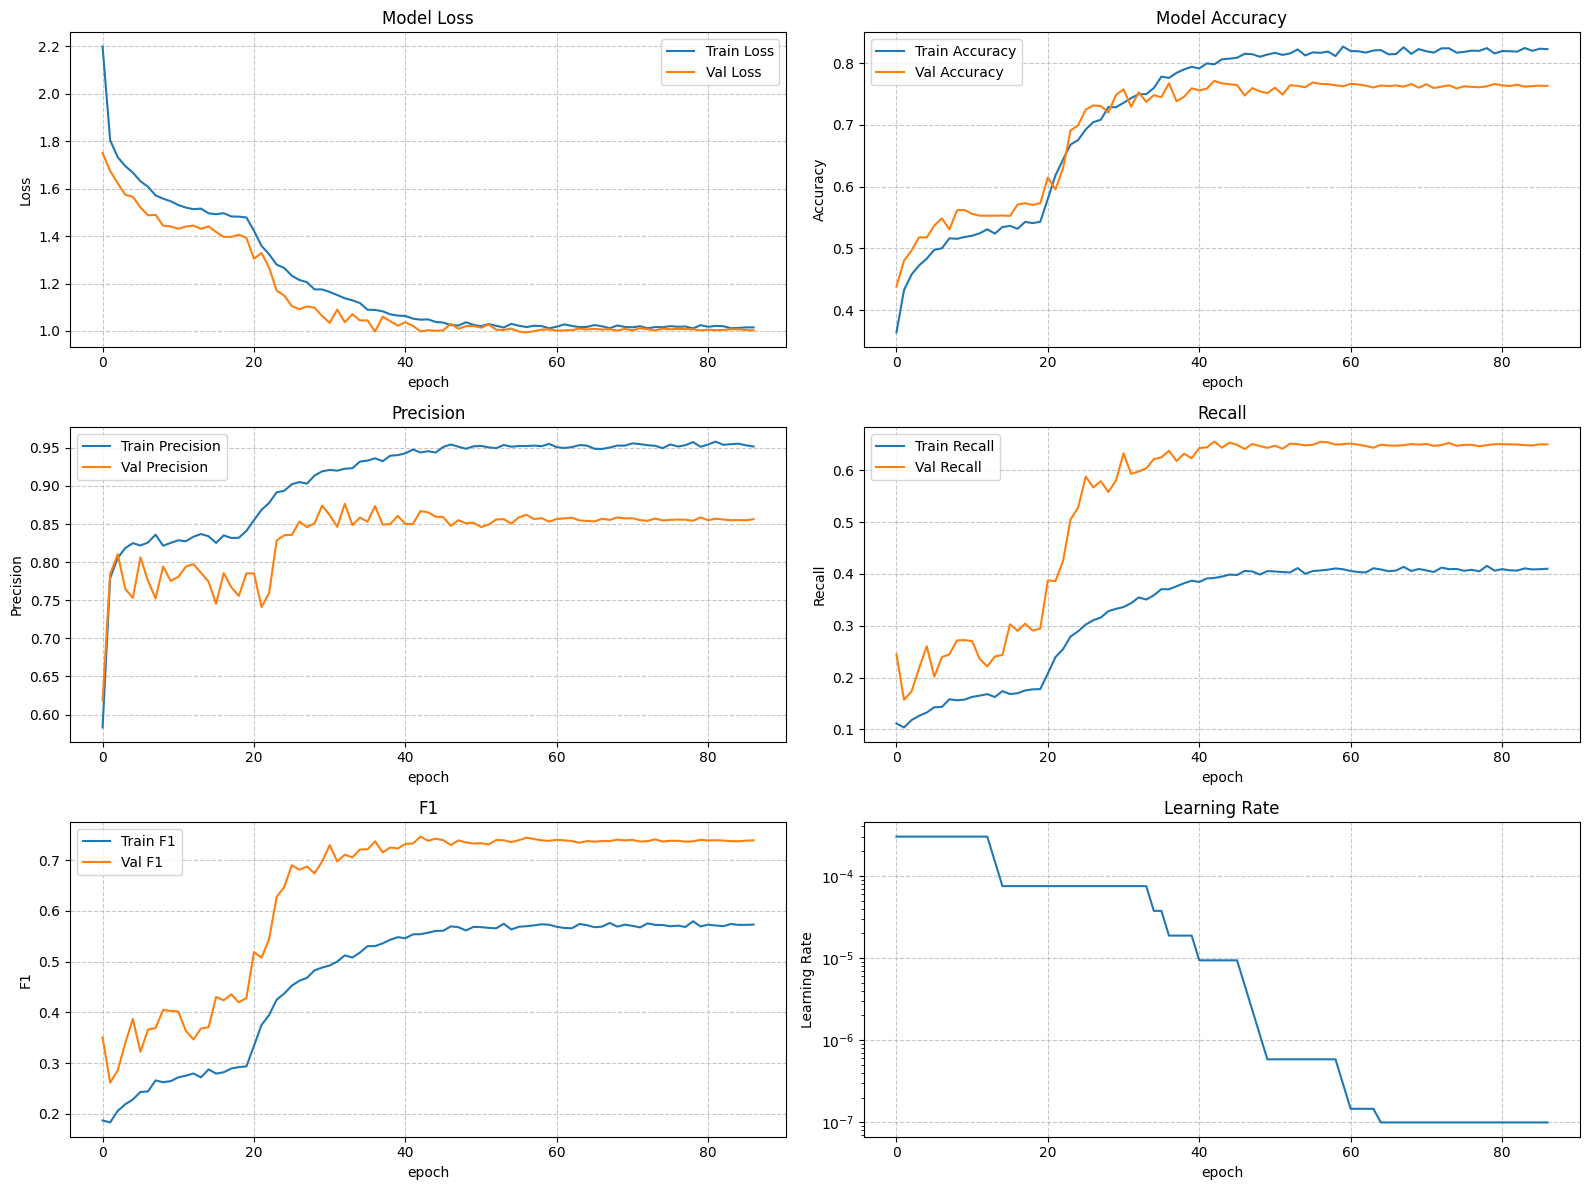

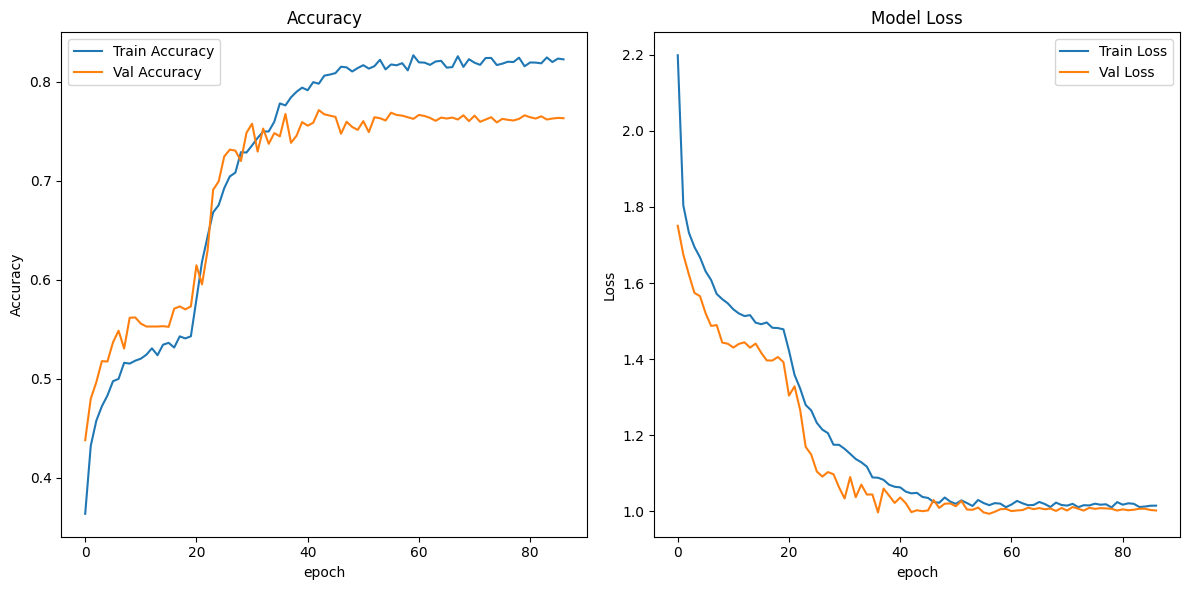

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
# 新增：VGG16 与 GAP 层、预处理函数
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 224, 224  # 使用VGG16推荐输入大小

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 16   # VGG16输入更大，适当减小batch以降低显存占用
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 使用与VGG16匹配的预处理：preprocess_input（'caffe'风格，BGR减均值），不要再rescale=1./255
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到VGG16适配的数据生成器（RGB + preprocess_input）。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（缓解类不平衡）
classes_array = train_generator.classes  # 0..K-1
class_counts = np.bincount(classes_array, minlength=len(class_labels))
total = classes_array.shape[0]
class_weights = {i: float(total / (len(class_labels) * max(1, class_counts[i]))) for i in range(len(class_labels))}
print("类别样本数:", dict(zip(class_labels, class_counts.tolist())))
print("类别权重:", class_weights)

# MixUp 生成器（同批内配对，避免跨epoch尺寸不一致）
def mixup_generator(generator, alpha=0.2):
    """对任意keras generator进行MixUp；每次仅使用一个batch内的随机配对。"""
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        b = x.shape[0]
        if b <= 1:
            # 只有1张图时跳过MixUp
            yield x, y
            continue
        lam = np.random.beta(alpha, alpha, size=b).astype(np.float32)
        idx = np.random.permutation(b)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x_mix = lam_x * x + (1.0 - lam_x) * x[idx]
        y_mix = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x_mix, y_mix

use_mixup = True
mixup_alpha = 0.2
train_generator_eff = mixup_generator(train_generator, alpha=mixup_alpha) if use_mixup else train_generator

# 使用预训练VGG16构建模型（两阶段训练 + 更强正则）
inputs = Input(shape=(img_width, img_height, 3))
weights_path = r"../vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
base_model = VGG16(weights=weights_path, include_top=False, input_tensor=inputs)

# 第一阶段：冻结全部卷积层，只训练分类头
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
# 缩小分类头，强化正则
x = Dense(256, activation='relu', kernel_regularizer=l2(5e-4))(x)
x = Dropout(0.5)(x)
outputs = Dense(len(class_labels), activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 使用标签平滑
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# 第一阶段编译（较大学习率以训练头部）
optimizer_stage1 = Adam(learning_rate=3e-4)
model.compile(optimizer=optimizer_stage1, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# 记录初始学习率供日志与绘图使用
initial_learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))

model.summary()

# 在创建回调前，确保目录存在
os.makedirs('models', exist_ok=True)
os.makedirs('logs',   exist_ok=True)

# 回调函数（以val_loss为准，泛化更稳）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=1
)

model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# 两阶段训练
epochs_stage1 = min(20, epochs // 3)
epochs_stage2 = epochs - epochs_stage1

print("\n开始阶段一（冻结卷积层，仅训练分类头）...")
history1 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_stage1,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,  # MixUp通常可不加权重
    verbose=1
)

# 阶段二：解冻block5进行微调，低学习率
for layer in base_model.layers:
    layer.trainable = layer.name.startswith('block5')

optimizer_stage2 = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_stage2, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

print("\n开始阶段二（解冻block5微调）...")
history2 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs_stage2,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,
    verbose=1
)

# 合并历史，便于后续绘图
def _merge_history(h1, h2):
    for k, v in h2.history.items():
        h1.history.setdefault(k, [])
        h1.history[k].extend(v)
    return h1

history = _merge_history(history1, history2)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练过程已完成。")

2025-10-09 03:40:21.138144: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 03:40:22.726992: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-09 03:40:28.701959: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-09 03:40:32.444213: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; 

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到VGG16适配的数据生成器（RGB + preprocess_input）。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别样本数: {'anger': 705, 'disgust': 717, 'fear': 281, 'happy': 4772, 'normal': 2524, 'sad': 1982, 'surprised': 1290}
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}
增强启用 - 随机擦除:True, MixUp(alpha=0.15, prob=0.5)


2025-10-09 03:40:48.348588: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-09 03:40:51.805649: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:42] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2025-10-09 03:40:51.805732: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3956 MB memory:  -> device: 0, name: B1.gpu.small, pci bus id: 0000:35:00.0, compute capability: 8.6


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

2025-10-09 03:41:03.928429: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2025-10-09 03:41:12.673191: W tensorflow/core/common_runtime/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.54GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-09 03:41:12.673247: W tensorflow/core/common_runtime/bfc_allocator.cc:290] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.54GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-10-09 03:41:12.994629: W tensorflow/core/common_runtime/bfc_allocator.cc:360] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, yo

  1/767 [..............................] - ETA: 3:12:35 - loss: 3.1151 - accuracy: 0.1250 - precision: 0.3750 - recall: 0.1000

2025-10-09 03:41:13.861813: I tensorflow/stream_executor/cuda/cuda_blas.cc:1614] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


767/767 [==============================] - ETA: 0s - loss: 2.2817 - accuracy: 0.3221 - precision: 0.4505 - recall: 0.1729
Epoch 1: val_loss improved from inf to 1.71158, saving model to models/fer2013_best_model.h5

Epoch 1/100
训练: 损失=2.2817, 准确率=0.3221
训练: 精确率=0.4505, 召回率=0.1729
验证: 损失=1.7116, 准确率=0.4501
验证: 精确率=0.5723, 召回率=0.2399
验证: F1分数=0.3381
已用时: 2.56分钟, 预计剩余: 253.71分钟
当前学习率: 0.000300
767/767 [==============================] - 154s 181ms/step - loss: 2.2817 - accuracy: 0.3221 - precision: 0.4505 - recall: 0.1729 - val_loss: 1.7116 - val_accuracy: 0.4501 - val_precision: 0.5723 - val_recall: 0.2399 - lr: 3.0000e-04
Epoch 2/20
767/767 [==============================] - ETA: 0s - loss: 1.8394 - accuracy: 0.4097 - precision: 0.5974 - recall: 0.1845
Epoch 2: val_loss improved from 1.71158 to 1.56969, saving model to models/fer2013_best_model.h5

Epoch 2/100
训练: 损失=1.8394, 准确率=0.4097
训练: 精确率=0.5974, 召回率=0.1845
验证: 损失=1.5697, 准确率=0.4922
验证: 精确率=0.6497, 召回率=0.2454
验证: F1分数=0.3563
已用时: 4.

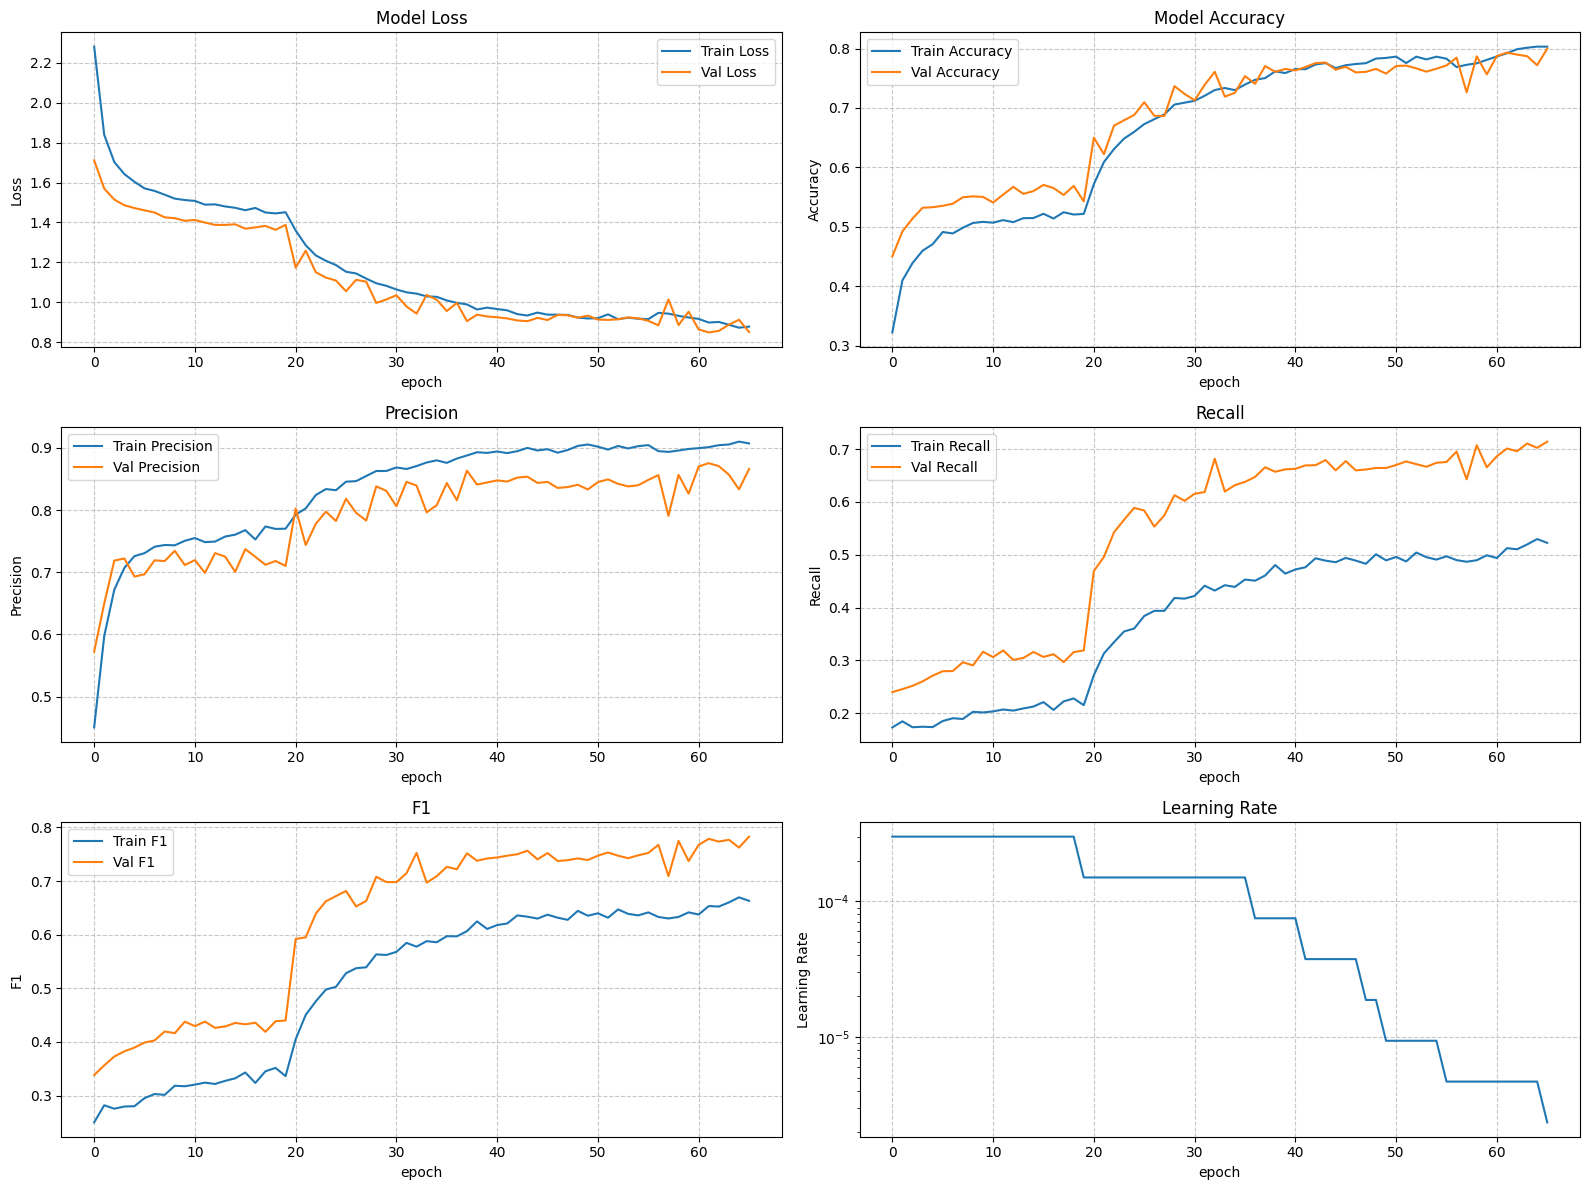

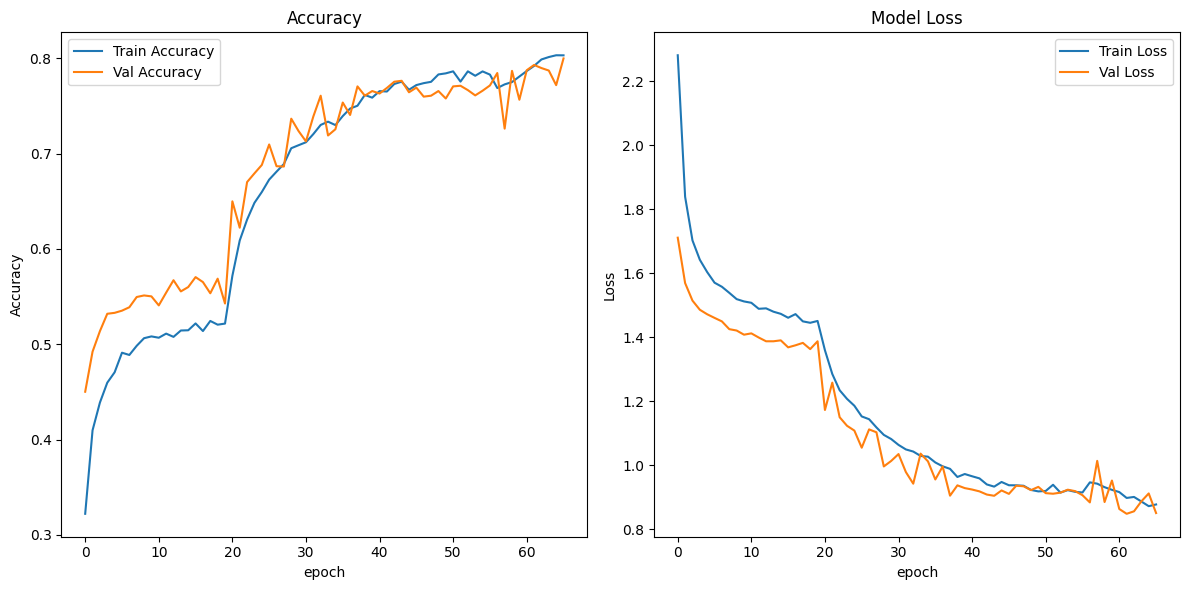

In [1]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
# 新增：VGG16 与 GAP 层、预处理函数
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False
from math import ceil

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 224, 224  # 使用VGG16推荐输入大小

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 16   # VGG16输入更大，适当减小batch以降低显存占用
epochs = 100       # 减少训练轮数以快速验证

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 使用与VGG16匹配的预处理：preprocess_input（'caffe'风格，BGR减均值），不要再rescale=1./255
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到VGG16适配的数据生成器（RGB + preprocess_input）。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（缓解类不平衡）
classes_array = train_generator.classes  # 0..K-1
class_counts = np.bincount(classes_array, minlength=len(class_labels))
total = classes_array.shape[0]
class_weights = {i: float(total / (len(class_labels) * max(1, class_counts[i]))) for i in range(len(class_labels))}
print("类别样本数:", dict(zip(class_labels, class_counts.tolist())))
print("类别权重:", class_weights)

# MixUp 生成器（同批内配对，避免跨epoch尺寸不一致）
def mixup_generator(generator, alpha=0.2):
    """对任意keras generator进行MixUp；每次仅使用一个batch内的随机配对。"""
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        b = x.shape[0]
        if b <= 1:
            # 只有1张图时跳过MixUp
            yield x, y
            continue
        lam = np.random.beta(alpha, alpha, size=b).astype(np.float32)
        idx = np.random.permutation(b)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x_mix = lam_x * x + (1.0 - lam_x) * x[idx]
        y_mix = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x_mix, y_mix

use_mixup = True
mixup_alpha = 0.2
train_generator_eff = mixup_generator(train_generator, alpha=mixup_alpha) if use_mixup else train_generator

# ========== 增强：随机擦除 +（概率）MixUp ==========
def random_erasing_generator(generator, p=0.4, sl=0.02, sh=0.2, r1=0.3, fill_mode='zero'):
    """Per-image 随机擦除：p 为应用概率，面积比例[sl,sh]，长宽比[r1,1/r1]。"""
    rng = np.random.default_rng()
    while True:
        x, y = next(generator)  # x:(B,H,W,C)
        B, H, W, C = x.shape
        for i in range(B):
            if rng.random() < p:
                area = H * W
                tgt = rng.uniform(sl, sh) * area
                asp = rng.uniform(r1, 1.0 / r1)
                h = int(round(np.sqrt(tgt * asp)))
                w = int(round(np.sqrt(tgt / asp)))
                if 0 < h < H and 0 < w < W:
                    top = rng.integers(0, H - h + 1)
                    left = rng.integers(0, W - w + 1)
                    patch = np.zeros((h, w, C), dtype=x.dtype) if fill_mode == 'zero' else rng.normal(0.0,1.0,(h,w,C)).astype(x.dtype)
                    x[i, top:top+h, left:left+w, :] = patch
        yield x, y

def mixup_generator_prob(generator, alpha=0.15, prob=0.5):
    """同批内 MixUp，按概率 prob 触发，降低过多软标签带来的欠拟合。"""
    rng = np.random.default_rng()
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        B = x.shape[0]
        if B <= 1 or rng.random() > prob:
            yield x, y
            continue
        lam = rng.beta(alpha, alpha, size=B).astype(np.float32)
        idx = rng.permutation(B)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x = lam_x * x + (1.0 - lam_x) * x[idx]
        y = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x, y

# 串联增强：先随机擦除，再（概率）MixUp
use_random_erasing = True
use_mixup = True
re_params = dict(p=0.4, sl=0.02, sh=0.2, r1=0.3, fill_mode='zero')
mixup_alpha, mixup_prob = 0.15, 0.5

train_generator_eff = train_generator
if use_random_erasing:
    train_generator_eff = random_erasing_generator(train_generator_eff, **re_params)
if use_mixup:
    train_generator_eff = mixup_generator_prob(train_generator_eff, alpha=mixup_alpha, prob=mixup_prob)

print(f"增强启用 - 随机擦除:{use_random_erasing}, MixUp(alpha={mixup_alpha}, prob={mixup_prob})")

# 使用预训练VGG16构建模型（两阶段训练 + 正则增强）
inputs = Input(shape=(img_width, img_height, 3))
weights_path = r"../vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
base_model = VGG16(weights=weights_path, include_top=False, input_tensor=inputs)

# 冻结卷积层
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)                         # 新增 BN 稳定头部分布
x = Dense(128, activation='relu', kernel_regularizer=l2(7e-4))(x)  # 256->128 + 更强L2
x = Dropout(0.6)(x)                                                # 0.5->0.6
outputs = Dense(len(class_labels), activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 标签平滑略降
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# 第一阶段编译（较大学习率以训练头部）
optimizer_stage1 = Adam(learning_rate=3e-4)
model.compile(optimizer=optimizer_stage1, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# 记录初始学习率供日志与绘图使用
initial_learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))

model.summary()

# 在创建回调前，确保目录存在
os.makedirs('models', exist_ok=True)
os.makedirs('logs',   exist_ok=True)

# 回调函数（以val_loss为准，泛化更稳）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=12,                      # 30 -> 12，更快提前停止防过拟合
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1,
    cooldown=1
)

model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# ========== 训练 ==========
epochs_stage1 = min(20, epochs // 3)
epochs_stage2 = epochs - epochs_stage1

# 完整步数（不丢最后一批）
steps_per_epoch = int(ceil(train_generator.samples / batch_size))
validation_steps = int(ceil(validation_generator.samples / batch_size))

print("\n开始阶段一（冻结卷积层，仅训练分类头）...")
history1 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_stage1,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,
    verbose=1
)

# 阶段二：解冻 block5
for layer in base_model.layers:
    layer.trainable = layer.name.startswith('block5')

optimizer_stage2 = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_stage2, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

print("\n开始阶段二（解冻block5微调）...")
history2 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_stage2,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,
    verbose=1
)

# 可选：阶段三，解冻 block4 + block5，极低LR进一步逼近>80%
enable_stage3 = True
if enable_stage3:
    for layer in base_model.layers:
        layer.trainable = layer.name.startswith('block4') or layer.name.startswith('block5')
    optimizer_stage3 = Adam(learning_rate=5e-6)
    model.compile(optimizer=optimizer_stage3, loss=loss_fn,
                  metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])
    print("\n开始阶段三（解冻block4+block5，超低LR微调 5-10 epoch）...")
    history3 = model.fit(
        train_generator_eff if use_mixup else train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=max(5, epochs // 10),
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
        class_weight=class_weights if not use_mixup else None,
        verbose=1
    )

    # 合并历史
    def _merge_history(h1, h2):
        for k, v in h2.history.items():
            h1.history.setdefault(k, []).extend(v)
        return h1
    history = _merge_history(_merge_history(history1, history2), history3)
else:
    # 原逻辑
    def _merge_history(h1, h2):
        for k, v in h2.history.items():
            h1.history.setdefault(k, []).extend(v)
        return h1
    history = _merge_history(history1, history2)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练过程已完成。")

启动FER2013情绪识别模型训练...
Python版本: 3.8.18 (default, Sep 11 2023, 13:40:15) 
[GCC 11.2.0]
TensorFlow版本: 2.10.1
使用训练集路径: ../RAF-DB/train
使用验证集路径: ../RAF-DB/test
Found 12271 images belonging to 7 classes.
Found 3068 images belonging to 7 classes.
已切换到VGG16适配的数据生成器（RGB + preprocess_input）。
情绪类别: ['anger', 'disgust', 'fear', 'happy', 'normal', 'sad', 'surprised']
类别样本数: {'anger': 705, 'disgust': 717, 'fear': 281, 'happy': 4772, 'normal': 2524, 'sad': 1982, 'surprised': 1290}
类别权重: {0: 2.4865248226950354, 1: 2.4449093444909344, 2: 6.238434163701068, 3: 0.3673512154233026, 4: 0.6945324881141046, 5: 0.884460141271443, 6: 1.3589147286821706}
增强启用 - 随机擦除:True, MixUp(alpha=0.15, prob=0.3)
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 

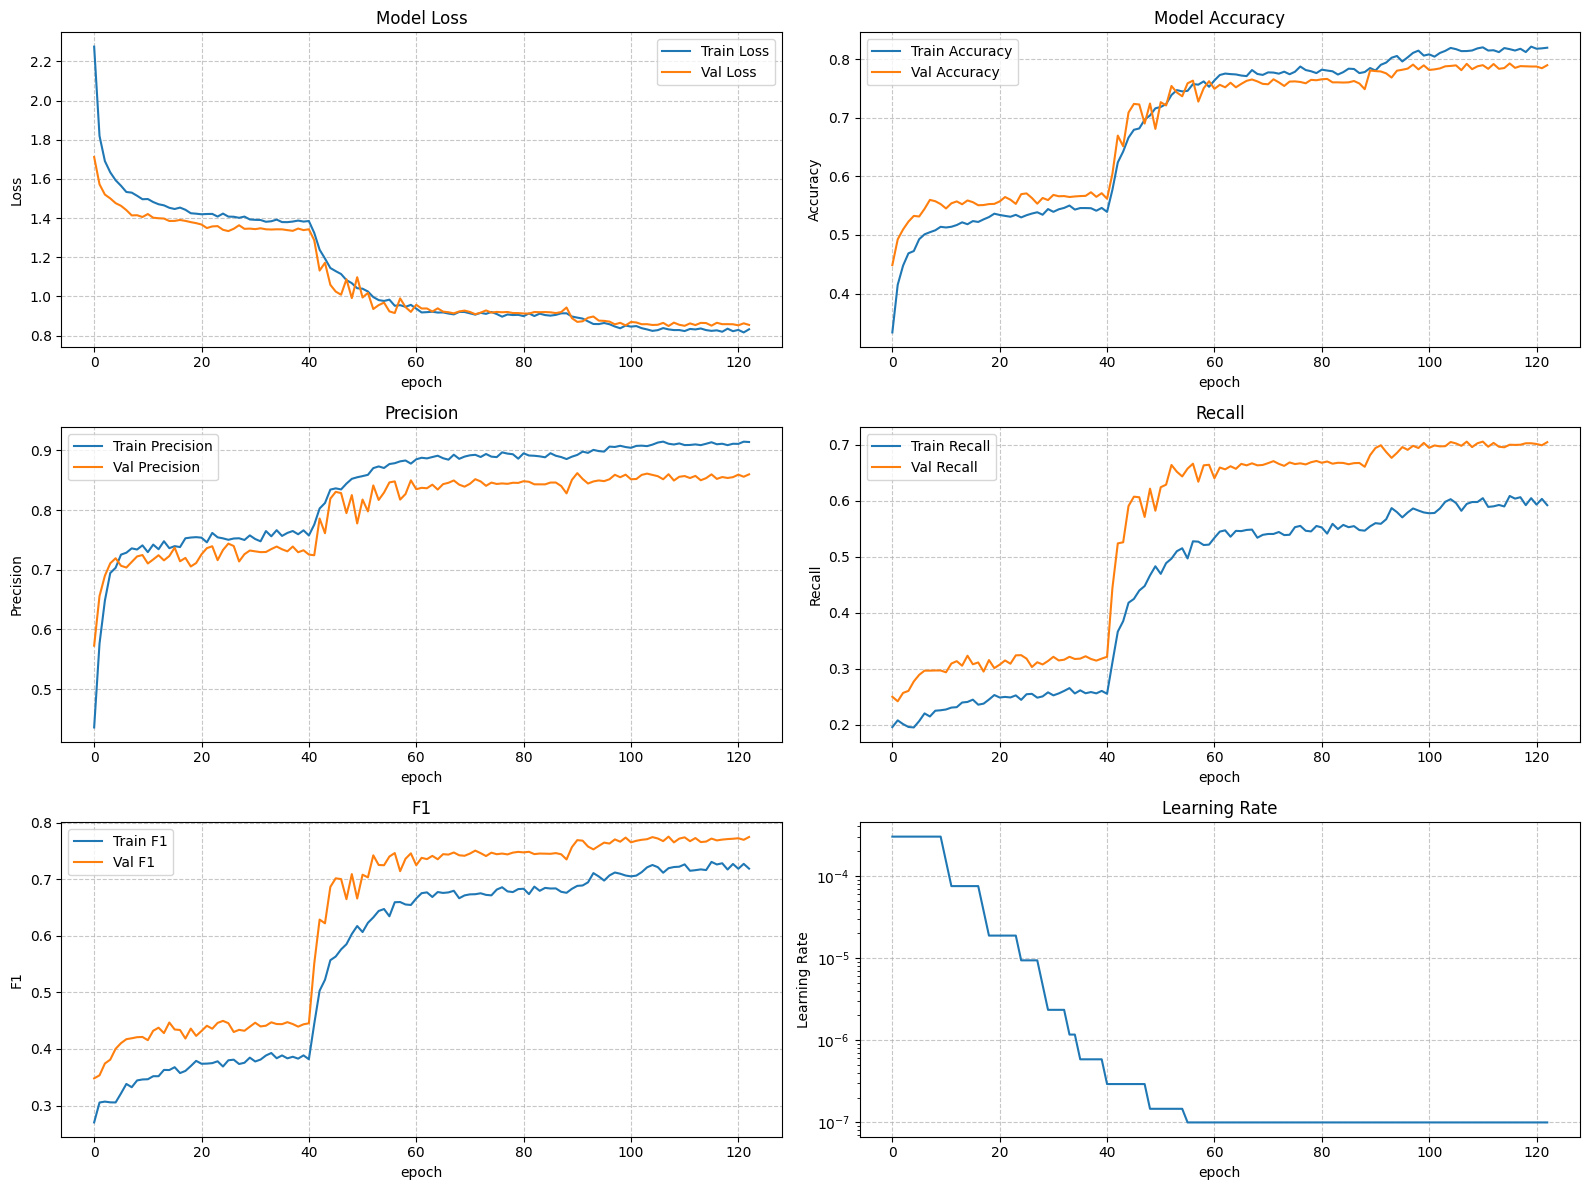

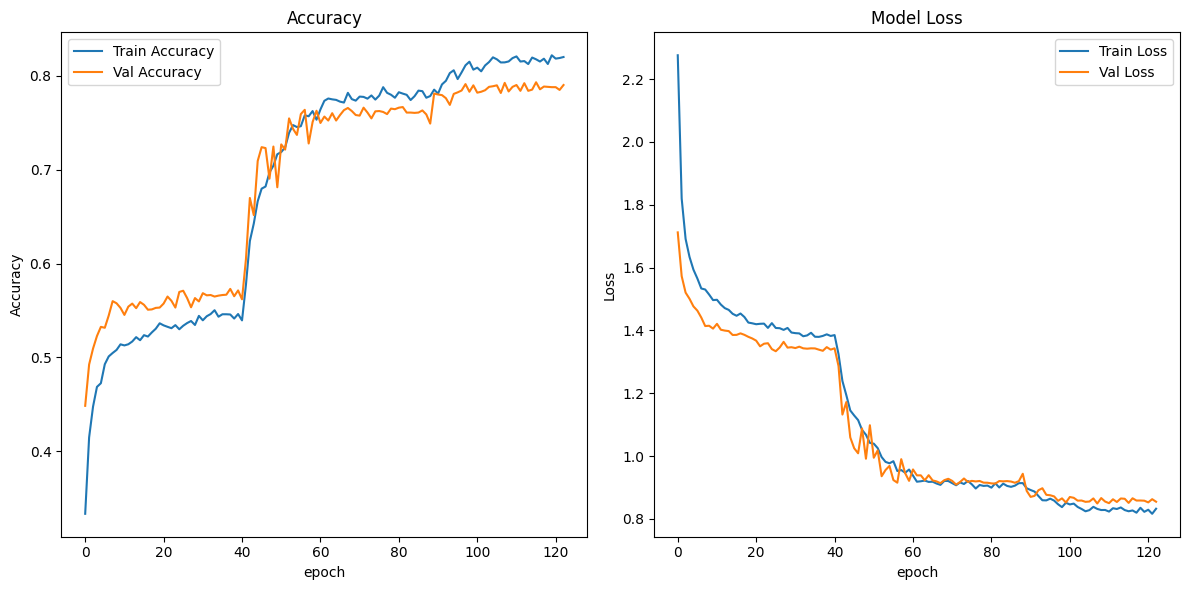

In [2]:
import os
import sys
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, LeakyReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall
# 新增：VGG16 与 GAP 层、预处理函数
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["DejaVu Sans"]   # 使用 DejaVu Sans
# 解决负号显示问题
plt.rcParams["axes.unicode_minus"] = False
from math import ceil

# 添加错误处理和日志记录
print("启动FER2013情绪识别模型训练...")
print(f"Python版本: {sys.version}")
print(f"TensorFlow版本: {tf.__version__}")

# 设置随机种子以保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 数据集路径（分别指定训练集与验证集）
train_dir = r"../RAF-DB/train"
val_dir = r"../RAF-DB/test"

# 检查数据集路径是否存在
if not os.path.isdir(train_dir):
    print(f"错误: 训练集路径 '{train_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)
if not os.path.isdir(val_dir):
    print(f"错误: 验证集路径 '{val_dir}' 不存在。请检查路径是否正确。")
    sys.exit(1)

print(f"使用训练集路径: {train_dir}")
print(f"使用验证集路径: {val_dir}")

# 图像参数 - 调整为更适合人脸处理的尺寸
# 处理后的人脸图像尺寸
processed_img_width, processed_img_height = 224, 224  # 使用VGG16推荐输入大小

# 原始输入图像尺寸（用于数据加载）
img_width, img_height = processed_img_width, processed_img_height

batch_size = 16   # VGG16输入更大，适当减小batch以降低显存占用
epochs = 180       # 增加总轮次，交给早停自动截断

# 设置人脸预处理参数 - 优化性能
face_detection_params = {
    'confidence_threshold': 0.9,  # 适度降低置信度阈值以提高检测速度
    'padding': 10,  # 适当减少填充以减少处理时间
    'grayscale': True  # 根据模型需求设置是否转换为灰度图
}

try:
        # 使用与VGG16匹配的预处理：preprocess_input（'caffe'风格，BGR减均值），不要再rescale=1./255
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            rotation_range=20,
            width_shift_range=0.15,
            height_shift_range=0.15,
            shear_range=0.2,
            zoom_range=0.2,
            horizontal_flip=True,
            vertical_flip=False,
            brightness_range=[0.8, 1.2],
            channel_shift_range=0.1
        )
        
        validation_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input
        )
        
        train_generator = train_datagen.flow_from_directory(
            train_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=True
        )

        validation_generator = validation_datagen.flow_from_directory(
            val_dir,
            target_size=(img_width, img_height),
            batch_size=batch_size,
            color_mode='rgb',             # 改为RGB
            class_mode='categorical',
            shuffle=False
        )
        print("已切换到VGG16适配的数据生成器（RGB + preprocess_input）。")
except Exception as e2:
        print(f"加载数据时出错: {str(e2)}")
        print("请确保数据集文件夹结构正确，并且包含正确的子文件夹。")
        print("建议运行install_dependencies.py来安装所有必要的依赖项。")
        sys.exit(1)

# 获取类别标签
class_labels = list(train_generator.class_indices.keys())
print("情绪类别:", class_labels)

# 计算类别权重（缓解类不平衡）
classes_array = train_generator.classes  # 0..K-1
class_counts = np.bincount(classes_array, minlength=len(class_labels))
total = classes_array.shape[0]
class_weights = {i: float(total / (len(class_labels) * max(1, class_counts[i]))) for i in range(len(class_labels))}
print("类别样本数:", dict(zip(class_labels, class_counts.tolist())))
print("类别权重:", class_weights)

# MixUp 生成器（同批内配对，避免跨epoch尺寸不一致）
def mixup_generator(generator, alpha=0.2):
    """对任意keras generator进行MixUp；每次仅使用一个batch内的随机配对。"""
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        b = x.shape[0]
        if b <= 1:
            # 只有1张图时跳过MixUp
            yield x, y
            continue
        lam = np.random.beta(alpha, alpha, size=b).astype(np.float32)
        idx = np.random.permutation(b)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x_mix = lam_x * x + (1.0 - lam_x) * x[idx]
        y_mix = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x_mix, y_mix

use_mixup = True
mixup_alpha = 0.2
train_generator_eff = mixup_generator(train_generator, alpha=mixup_alpha) if use_mixup else train_generator

# ========== 增强：随机擦除 +（概率）MixUp ==========
def random_erasing_generator(generator, p=0.4, sl=0.02, sh=0.2, r1=0.3, fill_mode='zero'):
    """Per-image 随机擦除：p 为应用概率，面积比例[sl,sh]，长宽比[r1,1/r1]。"""
    rng = np.random.default_rng()
    while True:
        x, y = next(generator)  # x:(B,H,W,C)
        B, H, W, C = x.shape
        for i in range(B):
            if rng.random() < p:
                area = H * W
                tgt = rng.uniform(sl, sh) * area
                asp = rng.uniform(r1, 1.0 / r1)
                h = int(round(np.sqrt(tgt * asp)))
                w = int(round(np.sqrt(tgt / asp)))
                if 0 < h < H and 0 < w < W:
                    top = rng.integers(0, H - h + 1)
                    left = rng.integers(0, W - w + 1)
                    patch = np.zeros((h, w, C), dtype=x.dtype) if fill_mode == 'zero' else rng.normal(0.0,1.0,(h,w,C)).astype(x.dtype)
                    x[i, top:top+h, left:left+w, :] = patch
        yield x, y

def mixup_generator_prob(generator, alpha=0.15, prob=0.5):
    """同批内 MixUp，按概率 prob 触发，降低过多软标签带来的欠拟合。"""
    rng = np.random.default_rng()
    while True:
        x, y = next(generator)       # x:(B,H,W,C) y:(B,K)
        B = x.shape[0]
        if B <= 1 or rng.random() > prob:
            yield x, y
            continue
        lam = rng.beta(alpha, alpha, size=B).astype(np.float32)
        idx = rng.permutation(B)
        lam_x = lam.reshape(-1, 1, 1, 1)
        lam_y = lam.reshape(-1, 1)
        x = lam_x * x + (1.0 - lam_x) * x[idx]
        y = lam_y * y + (1.0 - lam_y) * y[idx]
        yield x, y

# 串联增强：先随机擦除，再（概率）MixUp
use_random_erasing = True
use_mixup = True
re_params = dict(p=0.4, sl=0.02, sh=0.2, r1=0.3, fill_mode='zero')
mixup_alpha, mixup_prob = 0.15, 0.3   # 长训时略降MixUp概率，减轻欠拟合

train_generator_eff = train_generator
if use_random_erasing:
    train_generator_eff = random_erasing_generator(train_generator_eff, **re_params)
if use_mixup:
    train_generator_eff = mixup_generator_prob(train_generator_eff, alpha=mixup_alpha, prob=mixup_prob)

print(f"增强启用 - 随机擦除:{use_random_erasing}, MixUp(alpha={mixup_alpha}, prob={mixup_prob})")

# 使用预训练VGG16构建模型（两阶段训练 + 正则增强）
inputs = Input(shape=(img_width, img_height, 3))
weights_path = r"../vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"
base_model = VGG16(weights=weights_path, include_top=False, input_tensor=inputs)

# 冻结卷积层
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)                         # 新增 BN 稳定头部分布
x = Dense(128, activation='relu', kernel_regularizer=l2(7e-4))(x)  # 256->128 + 更强L2
x = Dropout(0.6)(x)                                                # 0.5->0.6
outputs = Dense(len(class_labels), activation='softmax')(x)
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# 标签平滑略降
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05)

# 第一阶段编译（较大学习率以训练头部）
optimizer_stage1 = Adam(learning_rate=3e-4)
model.compile(optimizer=optimizer_stage1, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

# 记录初始学习率供日志与绘图使用
initial_learning_rate = float(tf.keras.backend.get_value(model.optimizer.learning_rate))

model.summary()

# 在创建回调前，确保目录存在
os.makedirs('models', exist_ok=True)
os.makedirs('logs',   exist_ok=True)

# 回调函数（以val_loss为准，泛化更稳）
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,                      # 更长容忍度配合更大总轮次
    min_delta=0.002,                  # 若改善小于该阈值则视为无提升
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,        # 更快地下调学习率，加速后期收敛
    min_lr=1e-7,
    verbose=1,
    cooldown=1
)

model_checkpoint = ModelCheckpoint(
    filepath=os.path.join('models', 'fer2013_best_model.h5'),
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# CSV日志记录器
history_logger = CSVLogger(
    os.path.join('logs', 'training_history.csv'),
    append=False,
    separator=','
)

# 添加自定义回调以监控训练进度
class TrainingMonitor(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()
        print(f"开始训练... 预计训练轮数: {epochs}")
        print(f"使用优化器: {model.optimizer.__class__.__name__}")
        print(f"初始学习率: {initial_learning_rate}")
        print(f"Batch大小: {batch_size}")
        
    def on_epoch_end(self, epoch, logs=None):
        elapsed_time = time.time() - self.start_time
        remaining_time = (epochs - epoch - 1) * (elapsed_time / (epoch + 1)) / 60  # 预估剩余时间(分钟)
        
        # 打印更多指标
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"训练: 损失={logs['loss']:.4f}, 准确率={logs['accuracy']:.4f}")
        if 'precision' in logs and 'recall' in logs:
            print(f"训练: 精确率={logs['precision']:.4f}, 召回率={logs['recall']:.4f}")
        
        print(f"验证: 损失={logs['val_loss']:.4f}, 准确率={logs['val_accuracy']:.4f}")
        if 'val_precision' in logs and 'val_recall' in logs:
            print(f"验证: 精确率={logs['val_precision']:.4f}, 召回率={logs['val_recall']:.4f}")
        
        # 计算和打印F1分数
        if 'val_precision' in logs and 'val_recall' in logs and logs['val_precision'] + logs['val_recall'] > 0:
            val_f1 = 2 * (logs['val_precision'] * logs['val_recall']) / (logs['val_precision'] + logs['val_recall'])
            print(f"验证: F1分数={val_f1:.4f}")
        
        print(f"已用时: {elapsed_time/60:.2f}分钟, 预计剩余: {remaining_time:.2f}分钟")
        print(f"当前学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}")
        print("=" * 50)

# ========== 训练 ==========
# 新的三阶段配比：约 25% / 50% / 余下
epochs_stage1 = max(12, epochs // 4)
epochs_stage2 = max(60, epochs // 2)
epochs_stage3 = epochs - epochs_stage1 - epochs_stage2

# 完整步数（不丢最后一批）
steps_per_epoch = int(ceil(train_generator.samples / batch_size))
validation_steps = int(ceil(validation_generator.samples / batch_size))

print("\n开始阶段一（冻结卷积层，仅训练分类头）...")
history1 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_stage1,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,
    verbose=1
)

# 阶段二：解冻 block5
for layer in base_model.layers:
    layer.trainable = layer.name.startswith('block5')

optimizer_stage2 = Adam(learning_rate=1e-5)
model.compile(optimizer=optimizer_stage2, loss=loss_fn,
              metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])

print("\n开始阶段二（解冻block5微调）...")
history2 = model.fit(
    train_generator_eff if use_mixup else train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs_stage2,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
    class_weight=class_weights if not use_mixup else None,
    verbose=1
)

# 可选：阶段三，解冻 block4 + block5，极低LR进一步逼近>80%
enable_stage3 = True
if enable_stage3:
    for layer in base_model.layers:
        layer.trainable = layer.name.startswith('block4') or layer.name.startswith('block5')
    optimizer_stage3 = Adam(learning_rate=3e-6)  # 更低学习率做微调
    model.compile(optimizer=optimizer_stage3, loss=loss_fn,
                  metrics=['accuracy', Precision(name='precision'), Recall(name='recall')])
    print(f"\n开始阶段三（解冻block4+block5，超低LR微调 {epochs_stage3} epoch）...")
    history3 = model.fit(
        train_generator_eff if use_mixup else train_generator,
        steps_per_epoch=steps_per_epoch,
        epochs=max(5, epochs_stage3),
        validation_data=validation_generator,
        validation_steps=validation_steps,
        callbacks=[early_stopping, reduce_lr, model_checkpoint, history_logger, TrainingMonitor()],
        class_weight=class_weights if not use_mixup else None,
        verbose=1
    )

    # 合并历史
    def _merge_history(h1, h2):
        for k, v in h2.history.items():
            h1.history.setdefault(k, []).extend(v)
        return h1
    history = _merge_history(_merge_history(history1, history2), history3)
else:
    # 原逻辑
    def _merge_history(h1, h2):
        for k, v in h2.history.items():
            h1.history.setdefault(k, []).extend(v)
        return h1
    history = _merge_history(history1, history2)

# 保存最终模型
model_dir = 'models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, 'fer2013_final_model.h5')
model.save(model_path)
print(f"最终模型已保存为 '{model_path}'")
print(f"最佳模型已保存为 'models/fer2013_best_model.h5'")
print(f"训练日志已保存为 'logs/training_history.csv'")

# 加载最佳模型进行评估
try:
    print("\n评估最佳模型性能...")
    # 加载模型时提供自定义对象
    best_model = tf.keras.models.load_model(
        os.path.join('models', 'fer2013_best_model.h5'),
        custom_objects={'Precision': Precision, 'Recall': Recall}
    )
    
    # 评估模型 - 不直接解构返回值
    eval_results = best_model.evaluate(validation_generator, verbose=0)
    
    # 提取评估指标
    loss = eval_results[0]
    accuracy = eval_results[1]
    
    # 检查是否有额外的指标
    precision = recall = f1_score = 0
    if len(eval_results) > 2:
        precision = eval_results[2]
        if len(eval_results) > 3:
            recall = eval_results[3]
        if precision + recall > 0:
            f1_score = 2 * (precision * recall) / (precision + recall)
    
    print(f"验证集损失: {loss:.4f}")
    print(f"验证集准确率: {accuracy:.4f}")
    if len(eval_results) > 2:
        print(f"验证集精确率: {precision:.4f}")
    if len(eval_results) > 3:
        print(f"验证集召回率: {recall:.4f}")
        print(f"验证集F1分数: {f1_score:.4f}")
    
    # 保存评估结果到文件
    with open(os.path.join('logs', 'evaluation_results.txt'), 'w') as f:
        f.write(f"模型评估结果\n")
        f.write(f"验证集损失: {loss:.4f}\n")
        f.write(f"验证集准确率: {accuracy:.4f}\n")
        if len(eval_results) > 2:
            f.write(f"验证集精确率: {precision:.4f}\n")
        if len(eval_results) > 3:
            f.write(f"验证集召回率: {recall:.4f}\n")
            f.write(f"验证集F1分数: {f1_score:.4f}\n")
        f.write(f"\n训练参数:\n")
        f.write(f"初始学习率: {initial_learning_rate}\n")
        f.write(f"Batch大小: {batch_size}\n")
        f.write(f"训练轮数: {epochs}\n")
        f.write(f"最终学习率: {tf.keras.backend.get_value(model.optimizer.learning_rate):.6f}\n")
        f.write(f"\n类别标签: {class_labels}\n")
        
except Exception as e:
    print(f"评估模型时出错: {str(e)}")
    print("使用当前模型进行评估...")
    try:
        # 不直接解构返回值
        eval_results = model.evaluate(validation_generator, verbose=0)
        loss = eval_results[0]
        accuracy = eval_results[1]
        print(f"验证集损失: {loss:.4f}")
        print(f"验证集准确率: {accuracy:.4f}")
    except Exception as e2:
        print(f"再次评估失败: {str(e2)}")

# 绘制训练历史
try:
    print("\n绘制训练历史图表...")
    
    # 创建图表目录
    plots_dir = 'plots'
    if not os.path.exists(plots_dir):
        os.makedirs(plots_dir)
    
    # 绘制完整的训练历史图表
    plt.figure(figsize=(16, 12))
    
    # 1. 绘制损失曲线
    plt.subplot(3, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 2. 绘制准确率曲线
    plt.subplot(3, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 3. 如果有精确率和召回率指标，也绘制出来
    if 'precision' in history.history and 'val_precision' in history.history:
        plt.subplot(3, 2, 3)
        plt.plot(history.history['precision'], label='Train Precision')
        plt.plot(history.history['val_precision'], label='Val Precision')
        plt.title('Precision')
        plt.xlabel('epoch')
        plt.ylabel('Precision')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    if 'recall' in history.history and 'val_recall' in history.history:
        plt.subplot(3, 2, 4)
        plt.plot(history.history['recall'], label='Train Recall')
        plt.plot(history.history['val_recall'], label='Val Recall')
        plt.title('Recall')
        plt.xlabel('epoch')
        plt.ylabel('Recall')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        
        # 计算F1分数
        train_f1_scores = []
        val_f1_scores = []
        for p, r, vp, vr in zip(history.history['precision'], history.history['recall'],
                              history.history['val_precision'], history.history['val_recall']):
            train_f1 = 2 * (p * r) / (p + r) if (p + r) > 0 else 0
            val_f1 = 2 * (vp * vr) / (vp + vr) if (vp + vr) > 0 else 0
            train_f1_scores.append(train_f1)
            val_f1_scores.append(val_f1)
        
        plt.subplot(3, 2, 5)
        plt.plot(train_f1_scores, label='Train F1')
        plt.plot(val_f1_scores, label='Val F1')
        plt.title('F1')
        plt.xlabel('epoch')
        plt.ylabel('F1')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
    
    # 6. 绘制学习率变化
    plt.subplot(3, 2, 6)
    # 获取学习率历史
    lr_history = [initial_learning_rate]
    current_lr = initial_learning_rate
    for i in range(1, len(history.history['loss'])):
        # 模拟ReduceLROnPlateau的行为
        if i > 0 and 'val_accuracy' in history.history:
            # 检查是否在最近的patience轮中没有改善
            if i >= reduce_lr.patience:
                recent_val_acc = history.history['val_accuracy'][i-reduce_lr.patience:i]
                if len(recent_val_acc) > 0 and max(recent_val_acc) == recent_val_acc[0]:
                    current_lr *= reduce_lr.factor
                    current_lr = max(current_lr, reduce_lr.min_lr)
        lr_history.append(current_lr)
    
    plt.plot(lr_history)
    plt.title('Learning Rate')
    plt.xlabel('epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    
    # 保存完整的训练历史图表
    plt.savefig(os.path.join(plots_dir, 'training_history_full.png'), dpi=300, bbox_inches='tight')
    print("完整训练历史图表已保存。")
    
    # 保存单独的简化图表，便于快速查看
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Accuracy')
    plt.xlabel('epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(plots_dir, 'training_history_simple.png'))
    print("简化训练历史图表已保存。")
    
    # 在非交互式环境中不显示图表
    if os.environ.get('DISPLAY') or sys.platform == 'win32':
        plt.show()
    else:
        print("在无头环境中运行，跳过显示图表。")
    
except Exception as e:
    print(f"绘制图表时出错: {str(e)}")

print("\n训练过程已完成。")